<a href="https://colab.research.google.com/github/sharare-bazdar/Sharare-/blob/main/Predict_Gold_LTSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -----------------------------------------------[ Imports ]-------------------------------------------------


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
import tensorflow as tf
np.set_printoptions(suppress=True)

# ------------------------------------------[ Downloading Dataset & Info ]---------------------------------------------


In [ ]:
gold_ticker = "GC=F"
start_date = "2000-01-01"
end_date = "2025-04-02"

df_gold = yf.download(gold_ticker, start=start_date, end=end_date, multi_level_index=False)
df_gold = df_gold.drop(df_gold.columns[[1,2,3,4]], axis=1)

print(df_gold.head())

[*********************100%***********************]  1 of 1 completed

                 Close
Date                  
2000-08-30  273.899994
2000-08-31  278.299988
2000-09-01  277.000000
2000-09-05  275.799988
2000-09-06  274.200012


In [ ]:
df_gold.tail()

                  Close
Date                   
2025-03-26  3020.899902
2025-03-27  3060.199951
2025-03-28  3086.500000
2025-03-31  3122.800049
2025-04-01  3118.899902


In [ ]:
df_gold.isnull().sum()

Close    0
dtype: int64


In [ ]:
df_gold.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6168 entries, 2000-08-30 to 2025-04-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6168 non-null   float64
dtypes: float64(1)
memory usage: 96.4 KB


# ------------------------------------[ Dataset Visualization ]------------------------------------


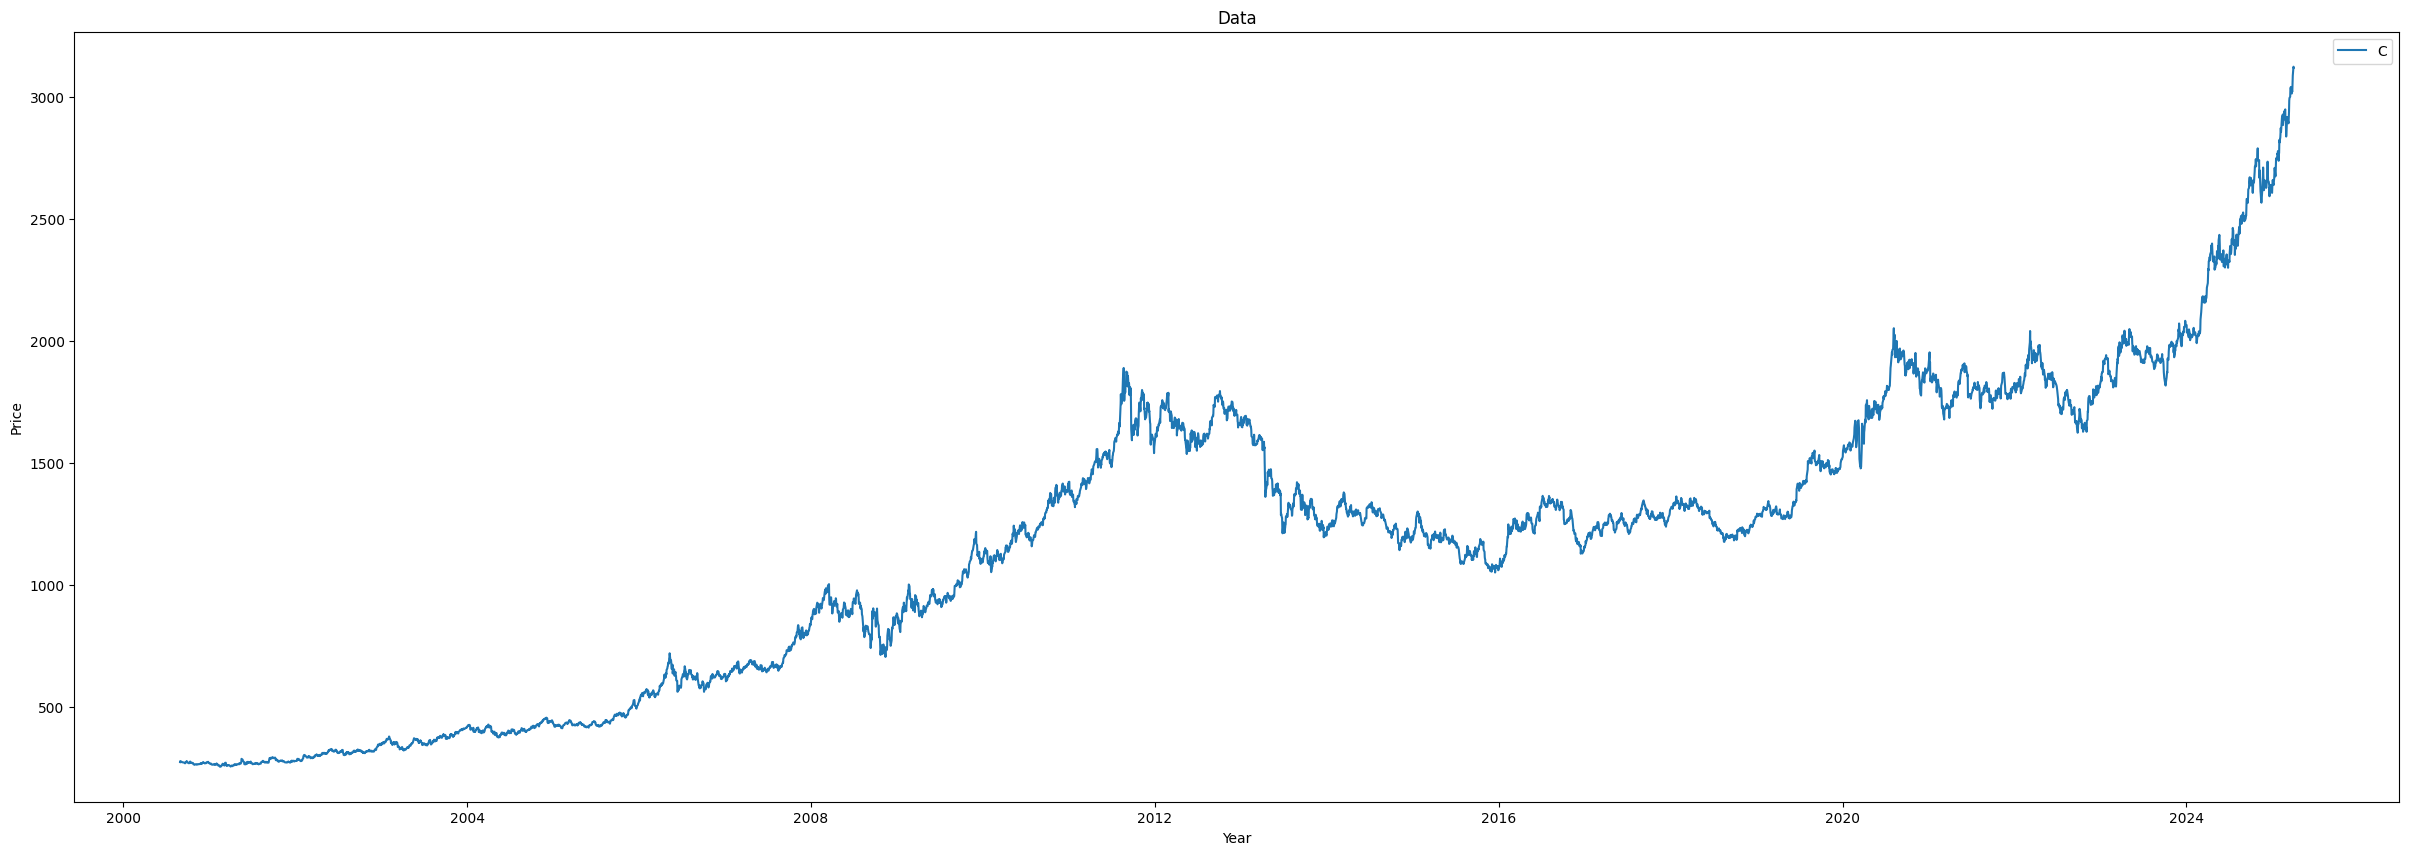

In [ ]:
plt.figure(figsize=(30,10))
plt.plot(df_gold.index,df_gold)
plt.legend('Close')
plt.title("Data")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

# ------------------------------------[ Dataset Preprocessing ]------------------------------------


In [ ]:
total_samples = len(df_gold)
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

train = df_gold.iloc[:train_size]
val = df_gold.iloc[train_size:train_size + val_size]
test = df_gold.iloc[train_size + val_size:]

In [ ]:
train.head()

,Close
Date,
2000-08-30,273.899994
2000-08-31,278.299988
2000-09-01,277.000000
2000-09-05,275.799988
2000-09-06,274.200012


In [ ]:
train

                  Close
Date                   
2000-08-30   273.899994
2000-08-31   278.299988
2000-09-01   277.000000
2000-09-05   275.799988
2000-09-06   274.200012
...                 ...
2017-11-10  1272.400024
2017-11-13  1277.300049
2017-11-14  1281.500000
2017-11-15  1276.500000
2017-11-16  1277.400024

[4317 rows x 1 columns]


In [ ]:
val.head()

,Close
Date,
2017-11-17,1295.800049
2017-11-20,1274.599976
2017-11-21,1281.099976
2017-11-22,1291.599976
2017-11-24,1286.699951


In [ ]:
test.head()

,Close
Date,
2021-07-27,1799.500000
2021-07-28,1799.500000
2021-07-29,1831.199951
2021-07-30,1812.599976
2021-08-02,1818.099976


In [ ]:
sequence_length = 30
batch_size = 32

train_generator = TimeseriesGenerator(train.values, train.values, length=sequence_length, batch_size=batch_size)
val_generator = TimeseriesGenerator(val.values, val.values, length=sequence_length, batch_size=batch_size)
test_generator = TimeseriesGenerator(test.values, test.values, length=sequence_length, batch_size=batch_size)

In [ ]:
X_batch, y_batch = train_generator[0]
print(f"X batch shape: {X_batch.shape}")
print(f"y batch shape: {y_batch.shape}")
print(f"y batch value: {y_batch[1]}")
print("Double-Checking , Making Sure Generator Works , Close Value : ",train.iloc[31]['Close'])

X batch shape: (32, 30, 1)
y batch shape: (32, 1)
y batch value: [272.3999939]
Double-Checking , Making Sure Generator Works , Close Value :  272.3999938964844


# ------------------------------------[ Model Architecture & Training ]------------------------------------


In [ ]:
model = models.Sequential([
    layers.InputLayer(input_shape=(sequence_length,1)),
    layers.LSTM(100,return_sequences=True,activation='relu'),
    layers.LSTM(50,return_sequences=True,activation='relu'),
    layers.LSTM(50,activation='relu'),

    layers.Dense(1)
])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                       │ (None, 30, 100)             │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_37 (LSTM)                       │ (None, 30, 50)              │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_38 (LSTM)                       │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 91,251 (356.45 KB)

 Trainable params: 91,251 (356.45 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00153),
              loss='mse',
              metrics=['mae'])

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                  patience=3,
                                                  restore_best_weights=True,
                                                  mode="min",
                                                  verbose=1)

In [ ]:
history = model.fit(train_generator,
                    epochs=100,
                    validation_data=val_generator,
                    callbacks=[early_stopping])

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - loss: 1608145.7500 - mae: 875.1464 - val_loss: 39126236.0000 - val_mae: 5562.5820
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2443458.2500 - mae: 857.5803 - val_loss: 51716.4883 - val_mae: 158.9407
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 17871.2090 - mae: 83.8606 - val_loss: 9315.8438 - val_mae: 62.0017
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4447.8247 - mae: 42.7899 - val_loss: 3274.1340 - val_mae: 41.2047
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3003.0508 - mae: 38.5625 - val_loss: 3144.0991 - val_mae: 41.7420
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2077.5452 - mae: 31.1425 - val_loss: 2806.4983 - val_mae: 40.1233
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 2400.3325 - mae: 32.7915 - val_loss: 3195.0100 - val_mae: 40.8745
Epoch 8/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 3013.1860 - mae: 37.0004 - val_loss:

# ---------------------------------[ Post-Training Evaluation & Visualization ]---------------------------------

In [ ]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


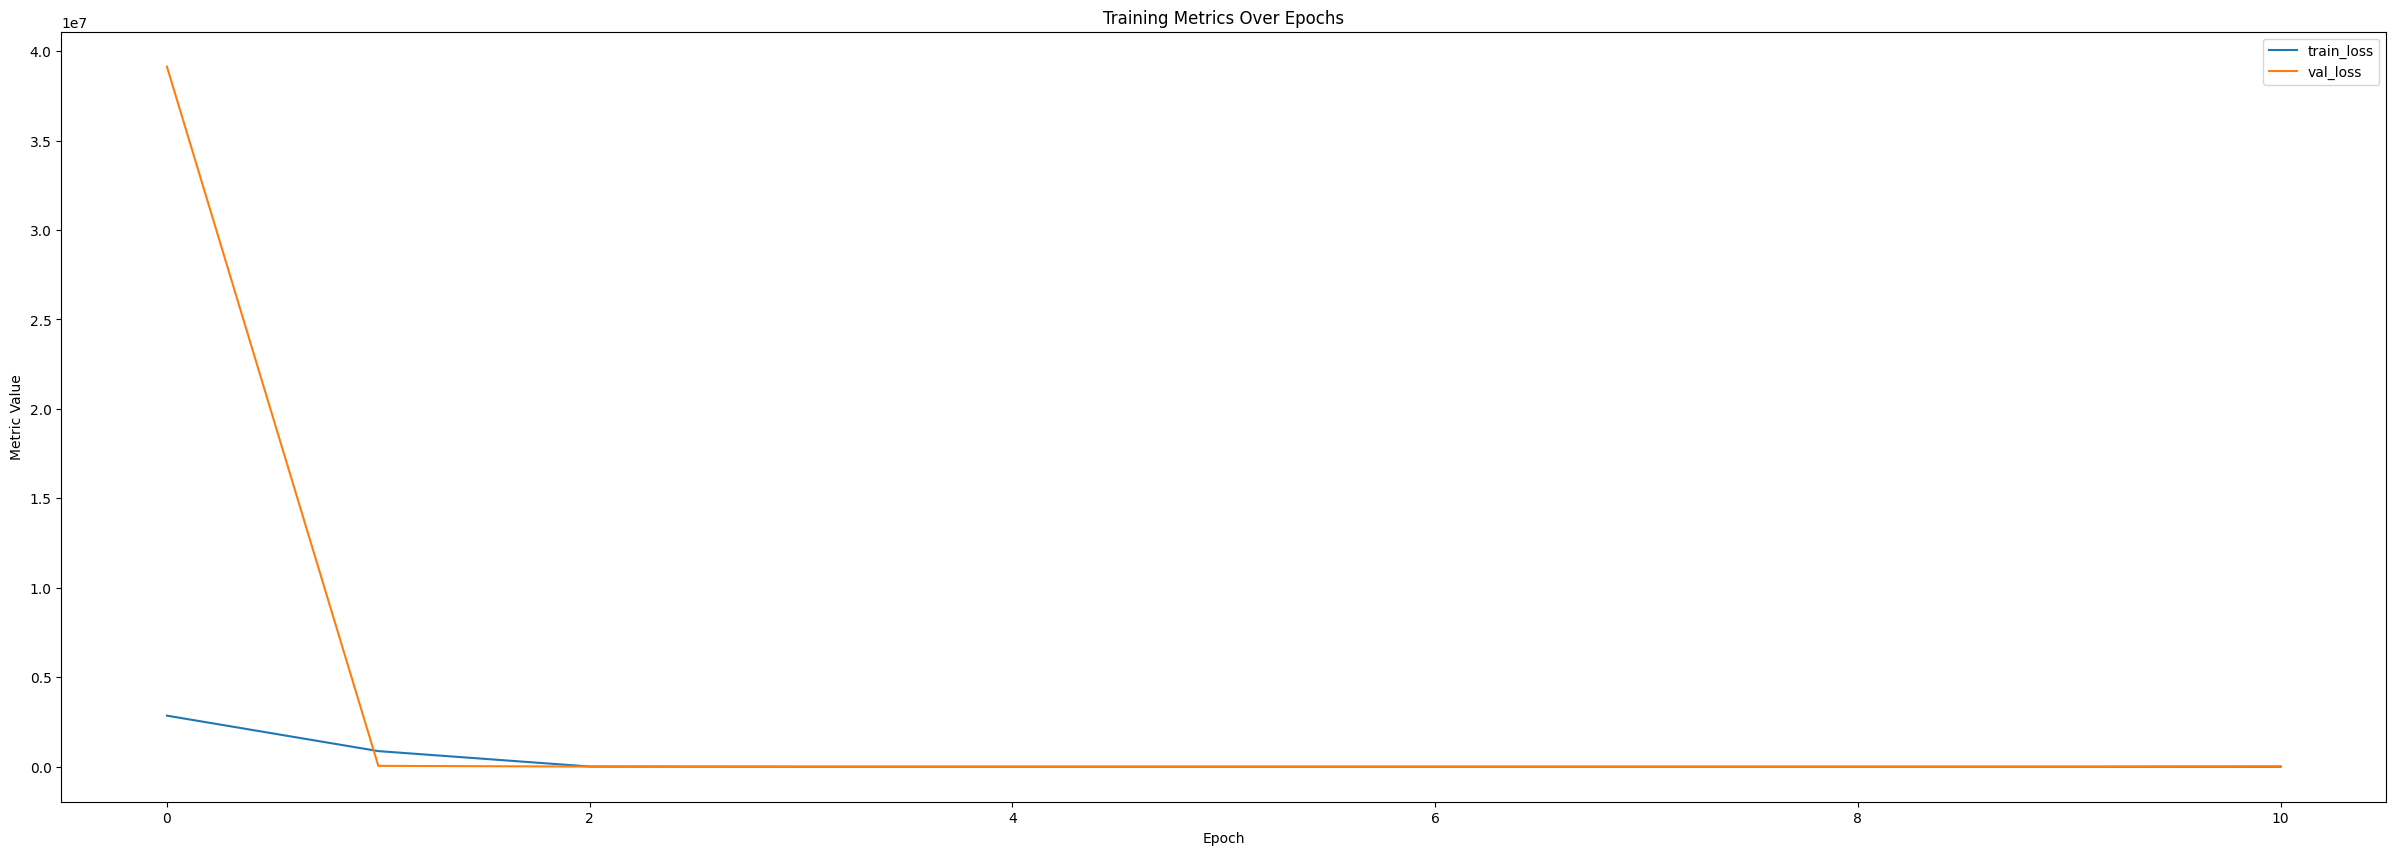

In [ ]:
plt.figure(figsize=(30,10))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Training Metrics Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.show()

In [ ]:
min_val_loss = min(history.history["val_loss"])
print("Minimum validation loss:", min_val_loss)

Minimum validation loss: 2687.753173828125


In [ ]:
test_results = model.evaluate(test_generator,verbose=1,return_dict=True)
print(test_results.keys())
print("Test Loss: {:.4f}".format(test_results["loss"]))
print("Test MAE: {:.4f}".format(test_results["mae"]))

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3659.5056 - mae: 48.7913
dict_keys(['loss', 'mae'])
Test Loss: 4560.2251
Test MAE: 54.0215


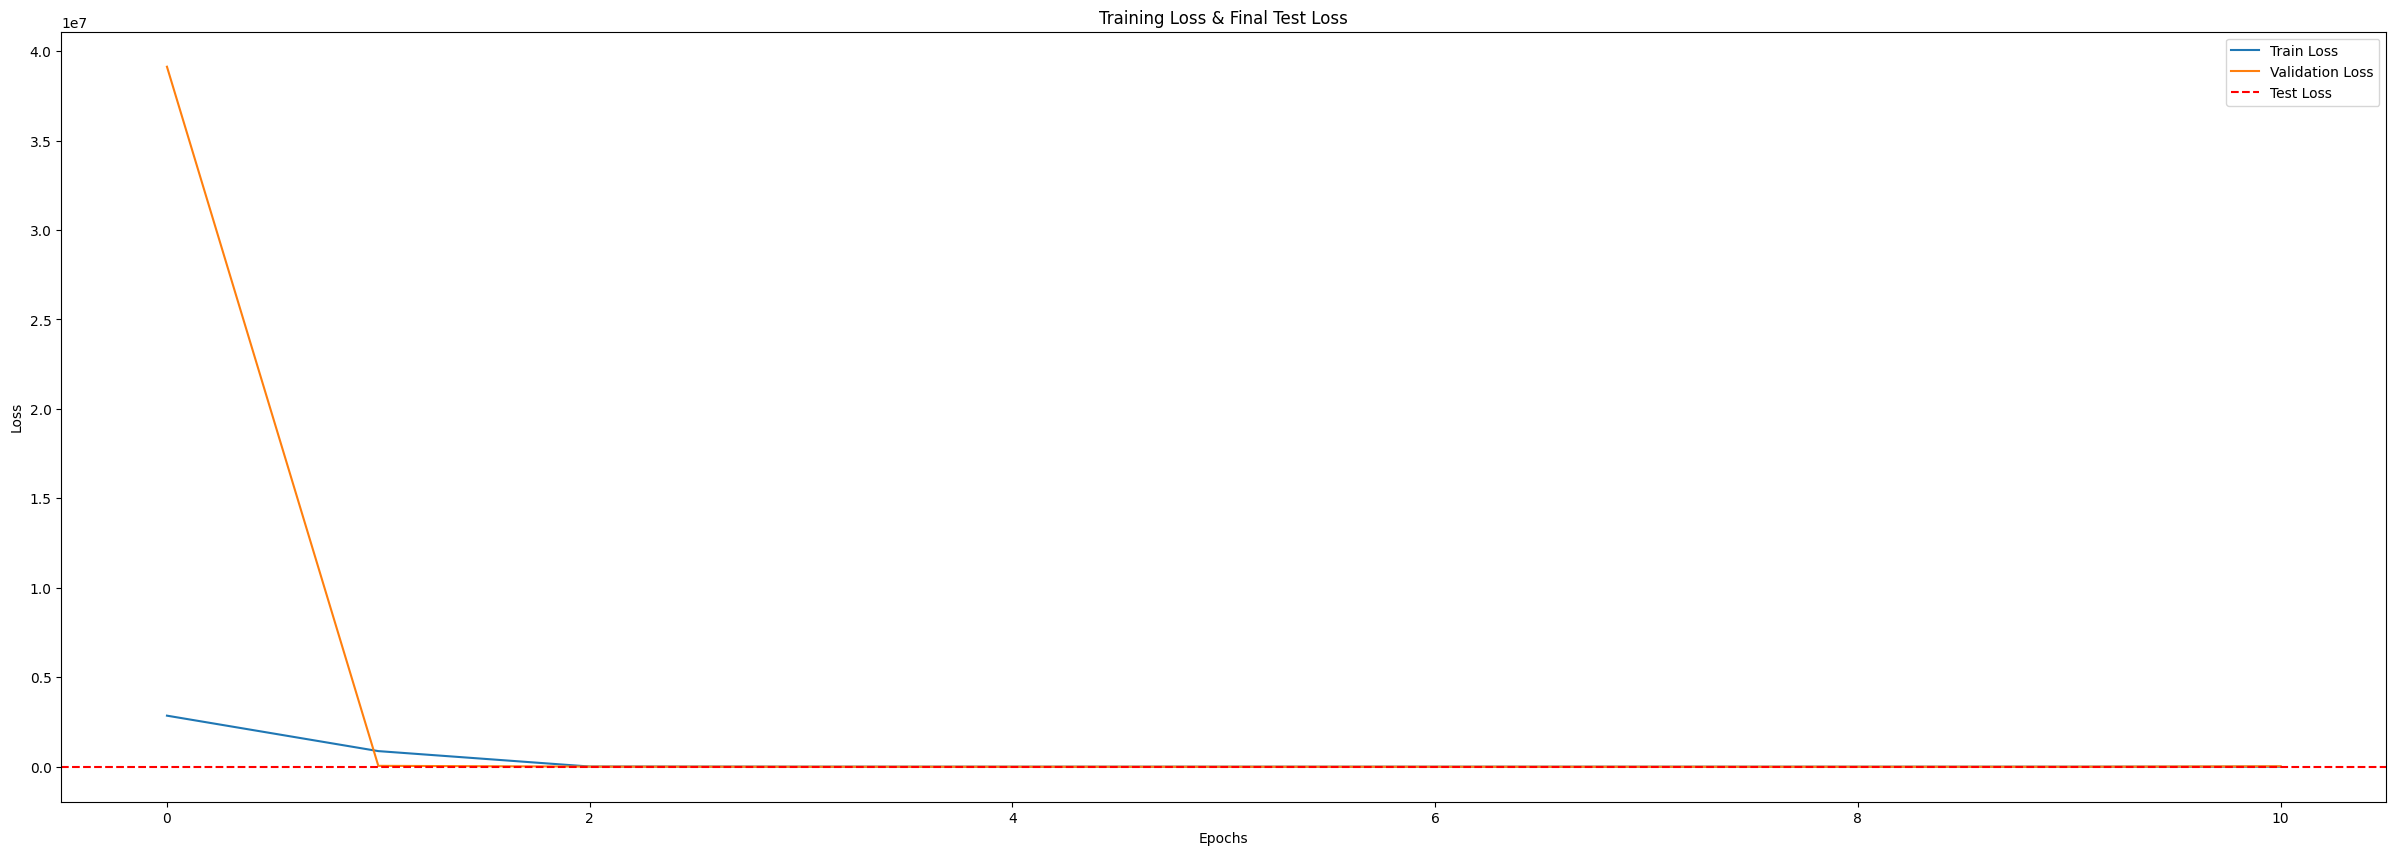

In [ ]:
plt.figure(figsize=(30, 10))
plt.plot(history.history["loss"], label="Train Loss")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Validation Loss")
plt.axhline(y=test_results["loss"], color="red", linestyle="--", label="Test Loss")
plt.legend()
plt.title("Training Loss & Final Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
def ext_gen(generator):
    X, Y = [], []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        X.append(x_batch)
        Y.append(y_batch)
    return np.vstack(X), np.vstack(Y)

X_train, Y_train = ext_gen(train_generator)
X_val, Y_val = ext_gen(val_generator)
X_train = np.concatenate((X_train, X_val), axis=0)
Y_train = np.concatenate((Y_train, Y_val), axis=0)
X_test, Y_test = ext_gen(test_generator)

In [ ]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [ ]:
print(math.sqrt(mean_squared_error(Y_train,train_predict)))

48.745538574749425


In [ ]:
print(math.sqrt(mean_squared_error(Y_test,test_predict)))

67.52943864809784


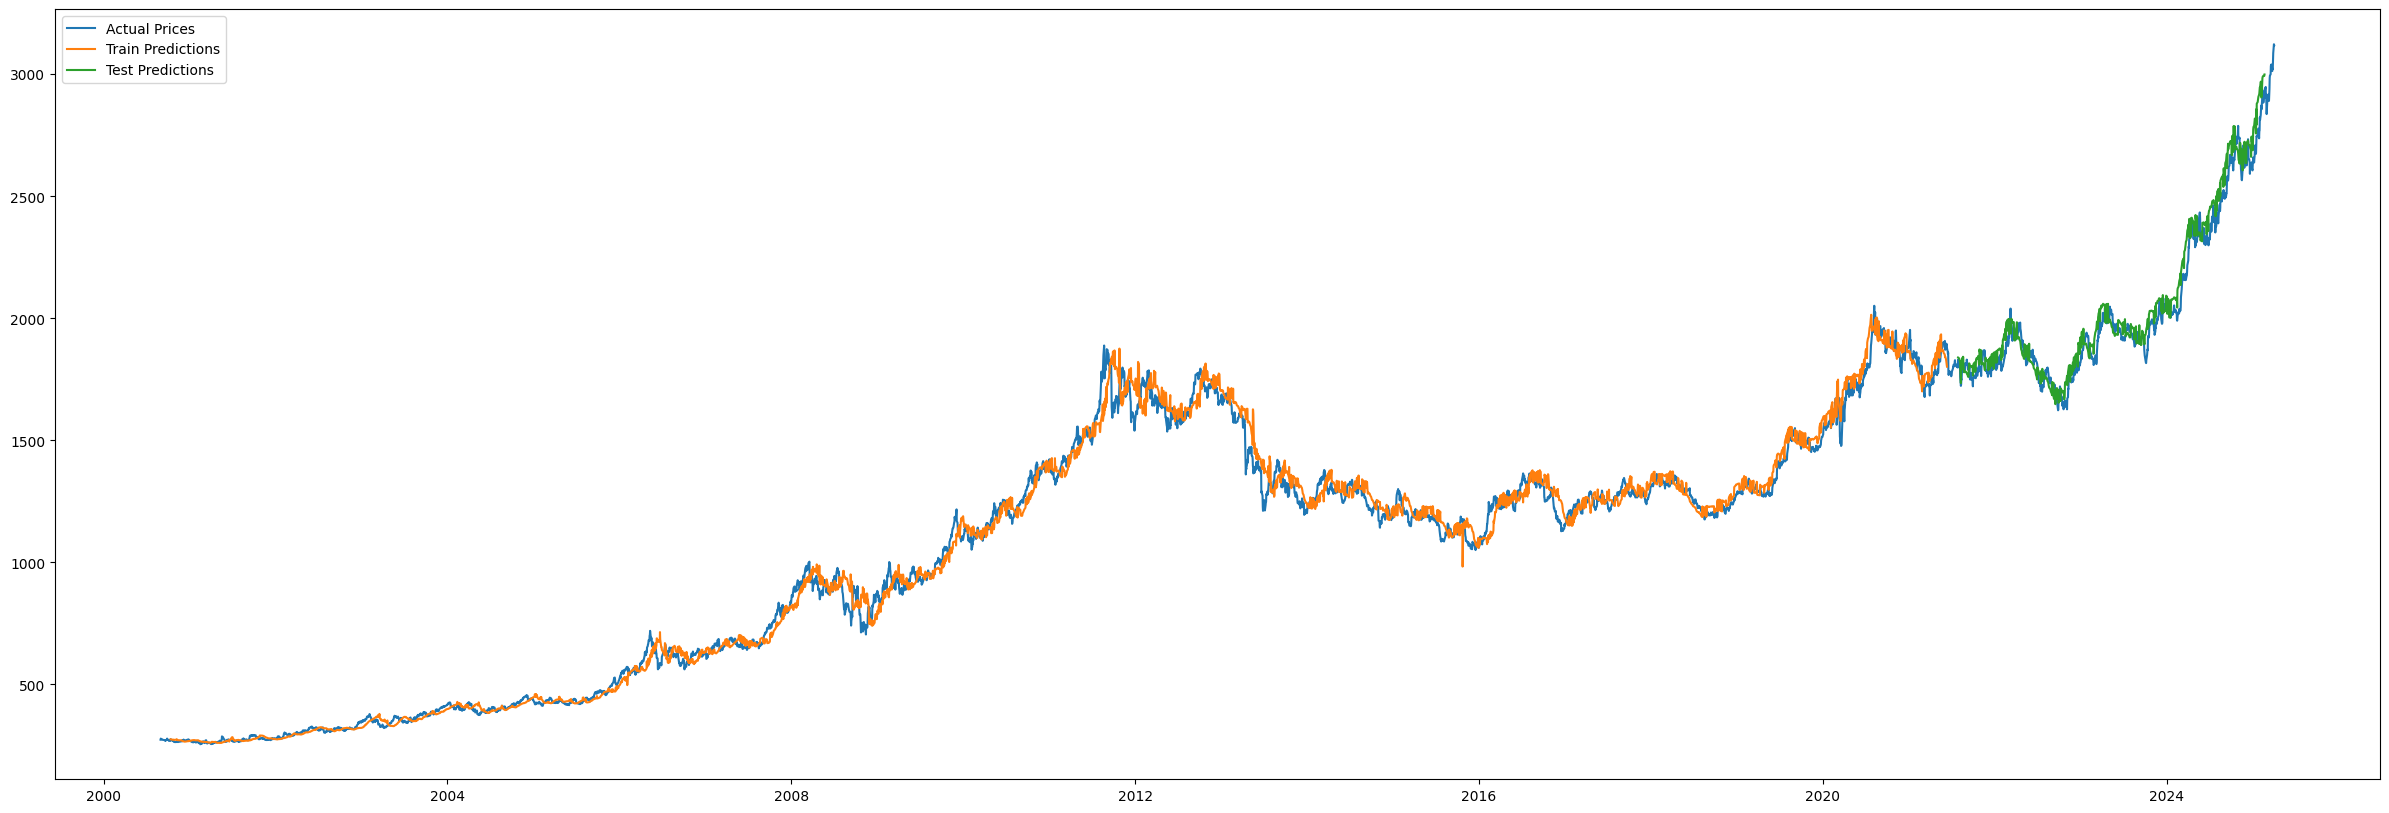

In [ ]:
df_array = df_gold['Close'].astype(float).values.reshape(-1, 1)

trainPredictPlot = np.empty_like(df_array)
trainPredictPlot[:, :] = np.nan
testPredictPlot = np.empty_like(df_array)
testPredictPlot[:, :] = np.nan
trainPredictPlot[sequence_length:len(train_predict) + sequence_length, :] = train_predict
test_start = len(train_predict) + (sequence_length * 2) + 1
testPredictPlot[test_start:test_start + len(test_predict), :] = test_predict
plt.figure(figsize=(30, 10))
plt.plot(df_gold.index, df_gold['Close'], label='Actual Prices')
plt.plot(df_gold.index, trainPredictPlot, label='Train Predictions')
plt.plot(df_gold.index, testPredictPlot, label='Test Predictions')
plt.legend()
plt.show()

# -------------------[ Future Prediction & Visualization ]-------------------

In [ ]:
test = test.to_numpy()
test[0:5]

array([[1799.5       ],
       [1799.5       ],
       [1831.19995117],
       [1812.59997559],
       [1818.09997559]])

In [ ]:
x_input = test[len(test)-sequence_length:]
len(x_input)

30

In [ ]:
print(x_input.shape)

(30, 1)


In [ ]:
temp_input = x_input.copy()
future_pred_results = np.empty((0, len(temp_input[0])), dtype=np.float32)

for i in range(1, 31):
    if temp_input.shape[0] > sequence_length:
        input_data = temp_input[-sequence_length:].reshape((1, sequence_length,1))
    else:
        input_data = temp_input.reshape((1, sequence_length, 1))

    pred_results = model.predict(input_data, verbose=0)
    pred_results = pred_results[0][0]

    temp_input = np.vstack((temp_input, pred_results))
    future_pred_results = np.vstack((future_pred_results, pred_results))

In [ ]:
start = "2025-04-03"
future_dates = pd.date_range(start,periods=30,freq='D').to_numpy()
last_30_dates = df_gold.iloc[-30:].index.values
last_30_Prices = df_gold['Close'].iloc[-30:].to_numpy()

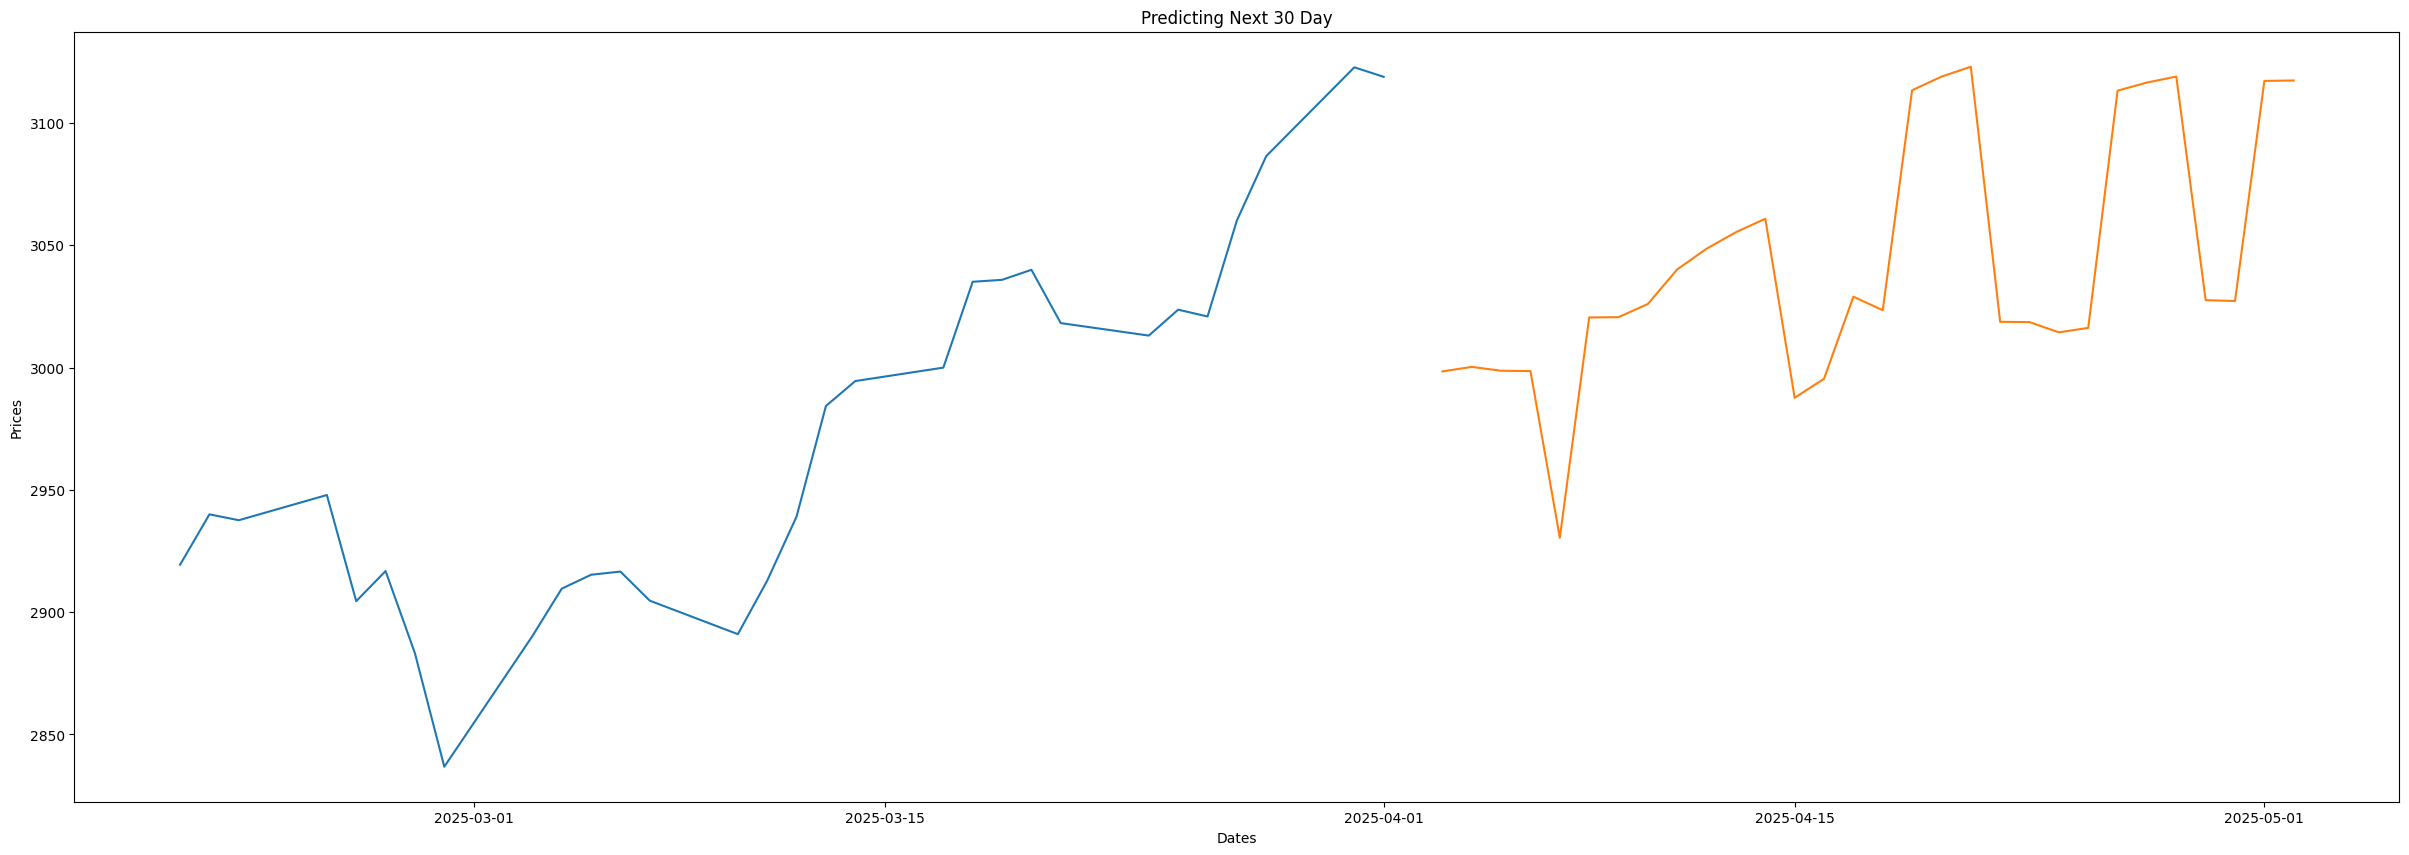

In [ ]:
plt.figure(figsize=(30,10))
plt.plot(last_30_dates,last_30_Prices)
plt.plot(future_dates,future_pred_results)
plt.title("Predicting Next {} Day".format(sequence_length))
plt.xlabel("Dates")
plt.ylabel("Prices")
plt.show()

In [ ]:
all_Prices = df_gold['Close'].iloc[:].to_numpy()
all_Prices = np.array(all_Prices) if not isinstance(all_Prices,np.ndarray) else all_Prices
all_Prices = all_Prices.reshape(-1,1)
all_prices = np.concatenate((all_Prices,future_pred_results))

all_dates = df_gold.iloc[:].index.values
all_dates = np.concatenate((all_dates,future_dates))

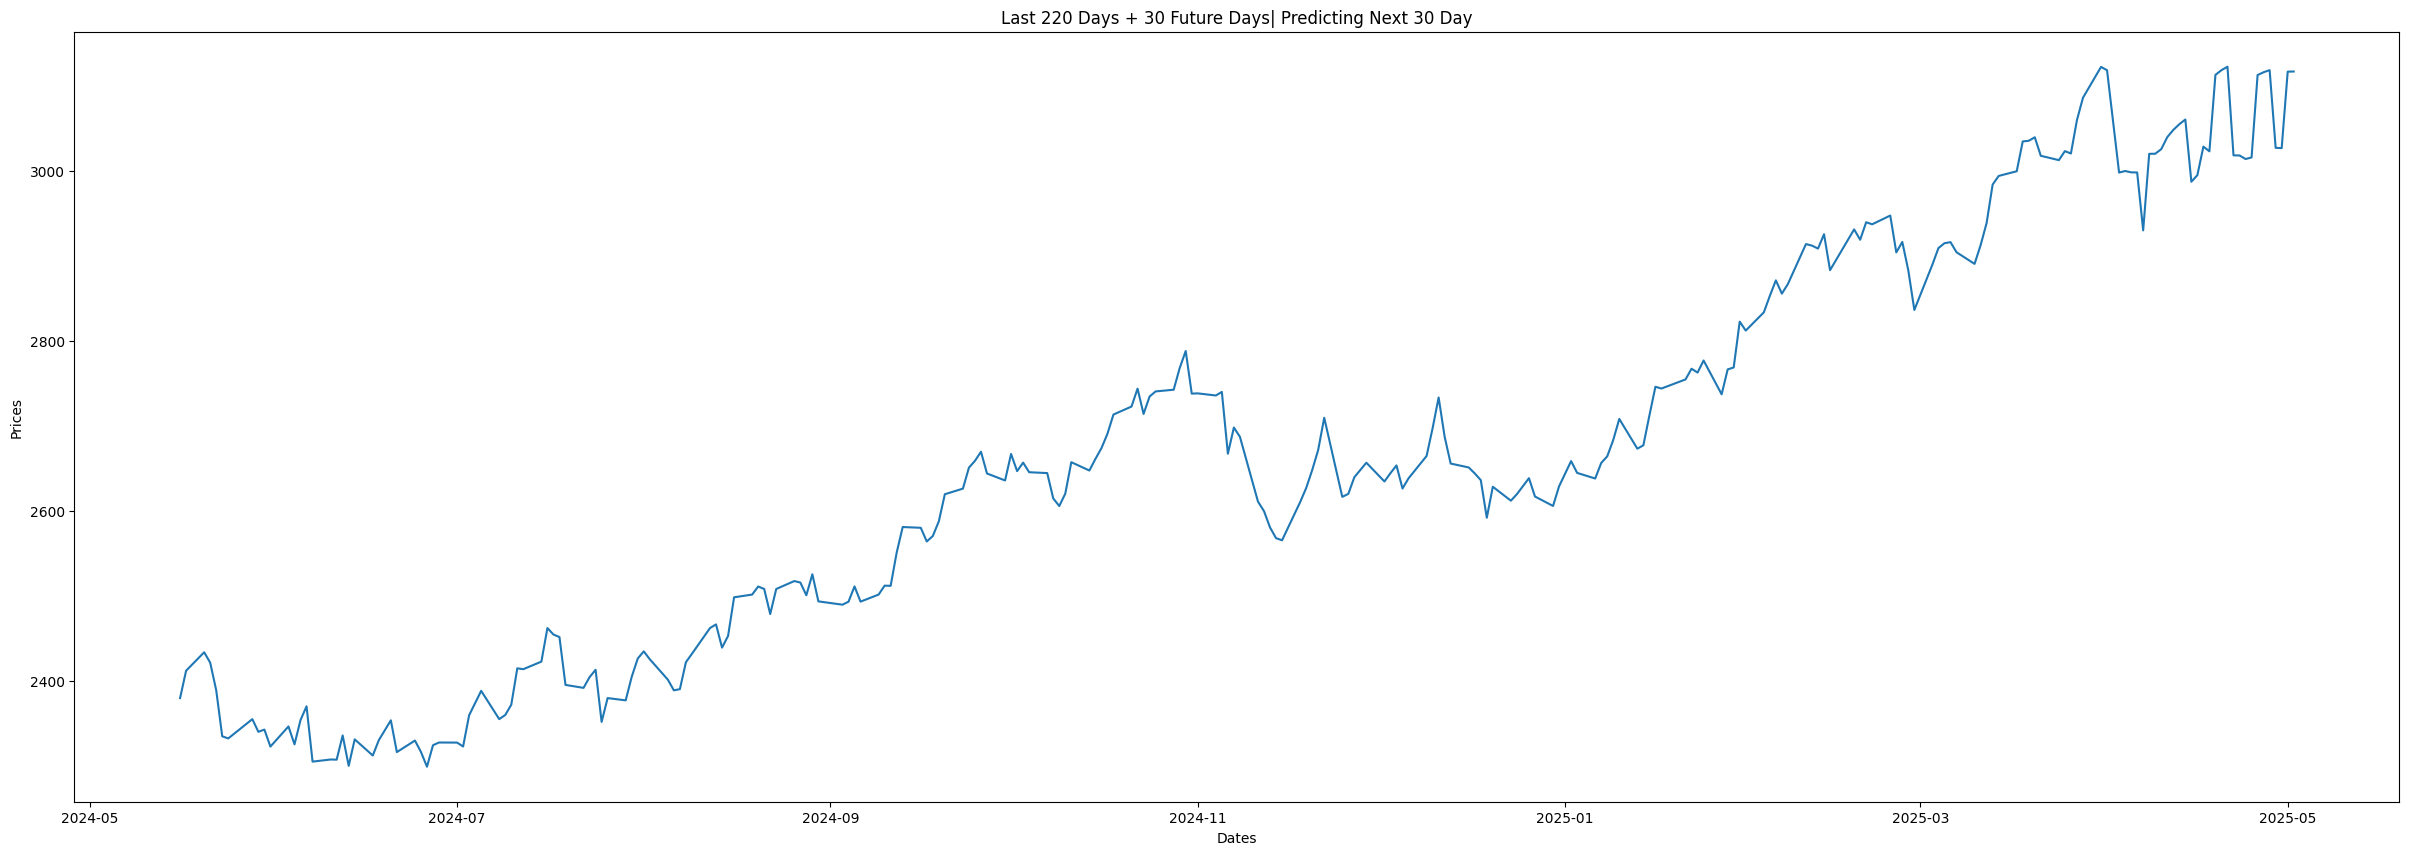

In [ ]:
#Last 220 Days + 30 Future Days
plt.figure(figsize=(30,10))
plt.plot(all_dates[-250:],all_prices[-250:])
plt.title("Last 220 Days + 30 Future Days| Predicting Next {} Day".format(sequence_length))
plt.xlabel("Dates")
plt.ylabel("Prices")
plt.show()

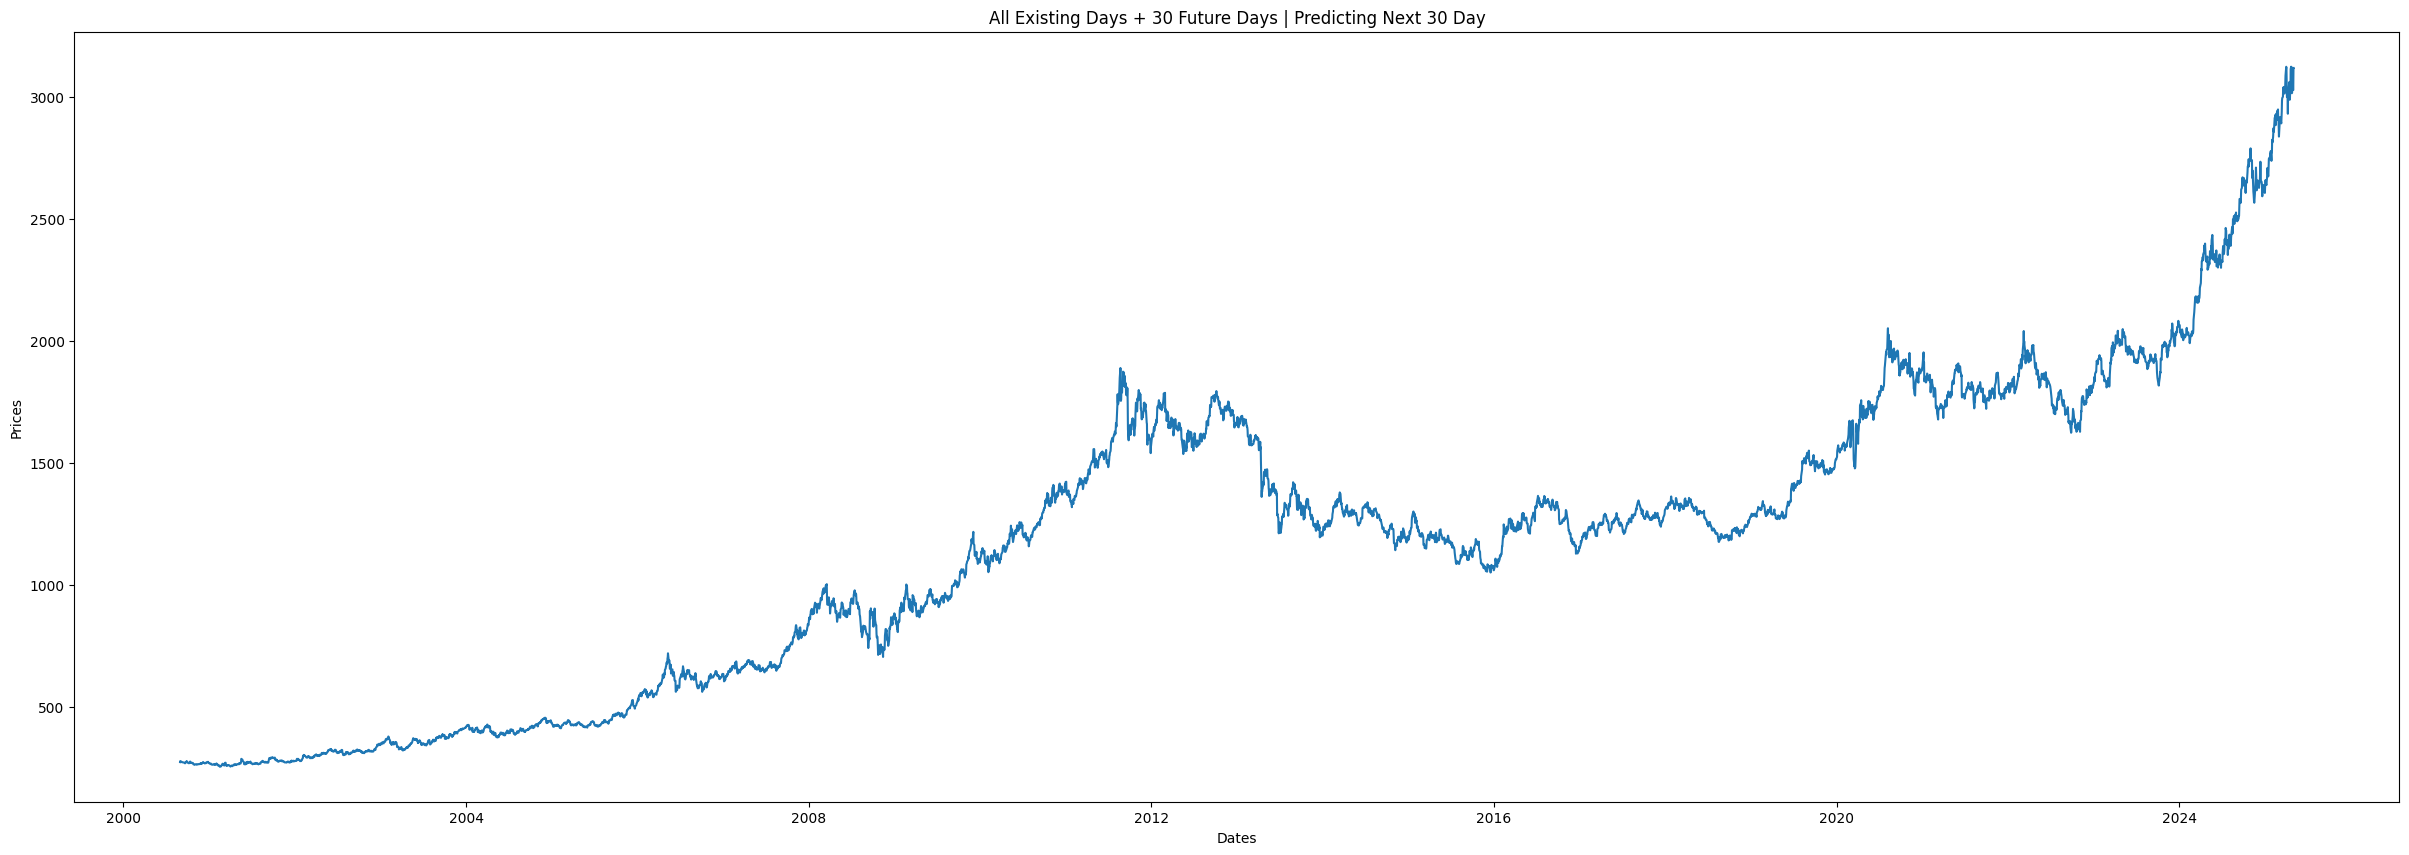

In [ ]:
#All Existing Days + 30 Future Days
plt.figure(figsize=(30,10))
plt.plot(all_dates,all_prices)
plt.title("All Existing Days + 30 Future Days | Predicting Next {} Day".format(sequence_length))
plt.xlabel("Dates")
plt.ylabel("Prices")
plt.show()